In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from haversine import haversine_vector
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)
import lightgbm as lgb
import shap


GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Preprocessing - GRAFT

the first step of the preprocessing is to load the dataset and inspect it

In [42]:
try:
    df
except NameError:
    df = pd.read_csv("./processed_1.csv", sep='|')

def sanity_check(df):
    print(df.head())
    print(df.describe())
    print(df.dtypes)
    return

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3410998 entries, 0 to 3410997
Data columns (total 26 columns):
 #   Column      Dtype  
---  ------      -----  
 0   ssn         str    
 1   cc_num      int64  
 2   first       str    
 3   last        str    
 4   gender      str    
 5   street      str    
 6   city        str    
 7   state       str    
 8   zip         int64  
 9   lat         float64
 10  long        float64
 11  city_pop    int64  
 12  job         str    
 13  dob         str    
 14  acct_num    int64  
 15  profile     str    
 16  trans_num   str    
 17  trans_date  str    
 18  trans_time  str    
 19  unix_time   int64  
 20  category    str    
 21  amt         float64
 22  is_fraud    int64  
 23  merchant    str    
 24  merch_lat   float64
 25  merch_long  float64
dtypes: float64(5), int64(6), str(15)
memory usage: 676.6 MB


In [44]:
df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long
0,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,263f4a79ad17a47197f43799a21569de,2025-06-25,03:35:14,1750815314,grocery_pos,357.41,1,fraud_Hudson-Ratke,40.084503,-75.389254
1,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,e02300c84182f711f2a9f9846f6ced13,2025-06-25,03:25:49,1750814749,shopping_pos,337.84,1,fraud_Pagac LLC,41.722363,-75.736086
2,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,f49e7c7d9a7ca2fbe997a294e5a59cd8,2025-06-25,03:57:10,1750816630,shopping_net,721.87,1,"fraud_Greenholt, O'Hara and Balistreri",40.353946,-76.193893
3,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,99df4ad40231b0de46b6e9bd73a128a9,2025-06-25,02:57:47,1750813067,grocery_pos,914.11,1,fraud_Schamberger-O'Keefe,39.910533,-75.510399
4,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,52b0bc313b62e84153697efdf8bb0780,2025-06-25,09:24:34,1750836274,misc_pos,550.26,1,"fraud_Cremin, Hamill and Reichel",40.641295,-75.923638


In [45]:
df.describe()

,cc_num,zip,lat,long,city_pop,acct_num,unix_time,amt,is_fraud,merch_lat,merch_long
count,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06,3.410998e+06
mean,3.188553e+17,5.181288e+04,3.753286e+01,-9.227034e+01,2.807726e+05,5.012861e+11,1.753076e+09,7.397749e+01,1.111346e-02,3.753258e+01,-9.227073e+01
std,1.154806e+18,2.955658e+04,5.217553e+00,1.630849e+01,5.310730e+05,2.907971e+11,9.056338e+06,1.671417e+02,1.048330e-01,5.249590e+00,1.631872e+01
min,6.040192e+10,1.007000e+03,1.965310e+01,-1.644361e+02,1.450000e+02,4.681899e+08,1.735686e+09,1.000000e+00,0.000000e+00,1.866024e+01,-1.654293e+02
25%,3.684538e+13,2.822700e+04,3.385840e+01,-9.932050e+01,1.780200e+04,2.539607e+11,1.745661e+09,9.220000e+00,0.000000e+00,3.378801e+01,-9.943941e+01
50%,3.502928e+15,4.822100e+04,3.824950e+01,-8.759380e+01,5.985300e+04,5.018392e+11,1.753207e+09,4.510000e+01,0.000000e+00,3.820623e+01,-8.736497e+01
75%,4.514627e+15,7.852100e+04,4.125230e+01,-8.022280e+01,2.326250e+05,7.519589e+11,1.761148e+09,8.307000e+01,0.000000e+00,4.130746e+01,-8.023021e+01
max,4.998442e+18,9.976200e+04,6.483930e+01,-6.784020e+01,2.906700e+06,9.999583e+11,1.767222e+09,2.263405e+04,1.000000e+00,6.583852e+01,-6.684023e+01


### Train/Test split
The dataset is heavily unbalanced w.r.t. the target variable (isFraud - ~1.1% positive).
We need to split without disrupting the distribution.
The test data will be only used for the final SL model evaluation. It will then be used in the RL section to try to learn a better policy.

In [46]:
y = df['is_fraud']
X = df.drop(columns=['is_fraud'])
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y, random_state=GLOBAL_SEED)

In [47]:
X

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,profile,trans_num,trans_date,trans_time,unix_time,category,amt,merchant,merch_lat,merch_long
0,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,rural,263f4a79ad17a47197f43799a21569de,2025-06-25,03:35:14,1750815314,grocery_pos,357.41,fraud_Hudson-Ratke,40.084503,-75.389254
1,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,rural,e02300c84182f711f2a9f9846f6ced13,2025-06-25,03:25:49,1750814749,shopping_pos,337.84,fraud_Pagac LLC,41.722363,-75.736086
2,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,rural,f49e7c7d9a7ca2fbe997a294e5a59cd8,2025-06-25,03:57:10,1750816630,shopping_net,721.87,"fraud_Greenholt, O'Hara and Balistreri",40.353946,-76.193893
3,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,rural,99df4ad40231b0de46b6e9bd73a128a9,2025-06-25,02:57:47,1750813067,grocery_pos,914.11,fraud_Schamberger-O'Keefe,39.910533,-75.510399
4,479-94-0888,4065133387262473,Danielle,Leblanc,F,108 Tanya Terrace Apt. 267,Aristes,PA,17920,40.8167,...,rural,52b0bc313b62e84153697efdf8bb0780,2025-06-25,09:24:34,1750836274,misc_pos,550.26,"fraud_Cremin, Hamill and Reichel",40.641295,-75.923638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410993,180-32-2108,630490686007,Vincent,Frank,M,90301 Mccall Dam Apt. 284,San Diego,CA,92105,32.7423,...,urban,3a9b1d3e8c446a63ee1bbebda406f8c5,2025-07-07,17:05:21,1751900721,shopping_pos,2.70,fraud_Mohr Inc,31.991091,-117.834865
3410994,180-32-2108,630490686007,Vincent,Frank,M,90301 Mccall Dam Apt. 284,San Diego,CA,92105,32.7423,...,urban,0d05a7b90bf8e17a65417e406a3c9813,2025-05-29,15:33:24,1748525604,misc_pos,3.19,fraud_Maggio-Fahey,32.483899,-117.977782
3410995,180-32-2108,630490686007,Vincent,Frank,M,90301 Mccall Dam Apt. 284,San Diego,CA,92105,32.7423,...,urban,7f8f846a63a5b095a94c9cd91478b73f,2025-10-22,20:49:11,1761158951,health_fitness,3.43,fraud_Schroeder Group,33.120791,-116.596519
3410996,180-32-2108,630490686007,Vincent,Frank,M,90301 Mccall Dam Apt. 284,San Diego,CA,92105,32.7423,...,urban,99d591ac40df58c494b65460e99e8b0a,2025-07-09,12:35:37,1752057337,shopping_pos,8.54,fraud_Torphy-Goyette,33.676122,-116.376649


## Feature selection and engineering
The dataset is large. After careful consideration, the following design choices were made:
#### legend:
* i = **i**ncluded as-is. 
* n = **n**ot included in the feature vector
* t = **t**ransformed
* l = could be informative, could be added **l**ater in case of underfitting

### Initial feature selection / preprocessing

| feature name   | decision (n / i / t) | notes |
|----------------|----------------------|-------|
| ssn            | n | not informative |
| cc_num         | n | unique per record, not informative |
| first          | n | not informative |
| last           | n | not informative |
| gender         | i | kept raw, LightGBM can work with categorial features without explicit encoding |
| street         | n | not informative |
| city           | n | not informative |
| state          | n | not informative |
| zip            | n | not informative |
| lat       | t | replaced with Haversine distance from lat_merchant / long_merchant |
|long| t | same as "lat"|
| city_pop       | i | kept raw |
| job            | n | weakly informative (only 6 observations per job) |
| dob            | t | transformed to age at transaction time (= 2025 − yob) |
| acct_num       | n | not informative |
| profile        | i | kept raw  |
| trans_num      | n | unique, not informative |
| trans_date     | t | month extracted (t: possible cyclical encoding with sin/cos) |
| trans_time     | t | hour extracted |
| unix_time      | n | redundant with date/time |
| category       | i | kept raw  |
| amt         | i | kept raw  |
| is_fraud        | i | target, kept raw |
| merchant       | l | could be replaced with mean_amount_merchant or excluded in favor of mean_amount_category |
| merch_lat   | t | used only in distance calculation |
| merch_long  | t | used only in distance calculation |


In [48]:
def deterministic_preprocessor(X):
    columns_to_drop = ['ssn','cc_num','first','last','street','city','state','zip','job','acct_num','trans_num','unix_time','merchant']
    X.drop(columns=columns_to_drop, inplace=True) #dropping useless columns

    #date processing
    X = X.rename(columns={'dob':'years', 'trans_date':'trans_month', 'trans_time':'trans_hour'})
    X['years'] = 2025 - pd.to_datetime(X['years']).dt.year
    X['trans_month'] = pd.to_datetime(X['trans_month']).dt.month
    X['trans_hour'] = pd.to_datetime(X['trans_hour'], format='%H:%M:%S').dt.hour


    #categorial feature fix for trees
    X[['gender', 'profile', 'category']] = X[['gender', 'profile', 'category']].astype('category')

    #dist calculation via haversine on lat,long,merch_lat,merch_long and subsequent drop of coordinates columns
    coords_1 = list(zip(X['lat'], X['long']))   #haversine accepts coordinates in (lat,long) format, so zipping is necessary
    coords_2 = list(zip(X['merch_lat'], X['merch_long'])) #same for merchant coordinates
    X['distance_km'] = haversine_vector(coords_1, coords_2)   #add column to dataset
    X.drop(columns=['lat','long','merch_lat','merch_long'], inplace=True) #dropping now-useless, distance columns
    return X


X_train = deterministic_preprocessor(X_train)
X_test =  deterministic_preprocessor(X_test)

sanity_check(X_train)

        gender  city_pop  years profile  trans_month  trans_hour  \
1945560      F      1096     64   rural            4           6   
213928       F    215808     32   urban            1           5   
1039590      F     11630     33   urban            9          14   
1944907      F      1573     52   rural            2           2   
2052988      F     92094     75   urban            9          23   

               category     amt  distance_km  
1945560     grocery_pos   80.42    90.421574  
213928    gas_transport   39.89    86.557921  
1039590  health_fitness    8.55    84.025125  
1944907   gas_transport  235.11    49.138834  
2052988  health_fitness   53.23    75.205141  
           city_pop         years   trans_month    trans_hour           amt  \
count  2.728798e+06  2.728798e+06  2.728798e+06  2.728798e+06  2.728798e+06   
mean   2.809800e+05  4.452411e+01  7.138317e+00  1.286420e+01  7.400958e+01   
std    5.311903e+05  1.748393e+01  3.417784e+00  6.828785e+00  1.687627e

In [49]:
#TODO this cell only serves to open "X_Train" in Data Wrangler
X_train

,gender,city_pop,years,profile,trans_month,trans_hour,category,amt,distance_km
1945560,F,1096,64,rural,4,6,grocery_pos,80.42,90.421574
213928,F,215808,32,urban,1,5,gas_transport,39.89,86.557921
1039590,F,11630,33,urban,9,14,health_fitness,8.55,84.025125
1944907,F,1573,52,rural,2,2,gas_transport,235.11,49.138834
2052988,F,92094,75,urban,9,23,health_fitness,53.23,75.205141
...,...,...,...,...,...,...,...,...,...
1826316,M,2383912,27,urban,7,15,shopping_pos,4.65,83.846409
1683981,M,65336,41,urban,11,17,home,8.47,73.401009
1656558,M,386505,34,urban,1,1,gas_transport,1.02,122.151084
1265939,M,21222,30,urban,8,16,food_dining,11.55,137.773864


# Section II - Supervised Learning
In this section we address the first phase of the project: training a model to output $P(x = \text{fraud})$.
## Gradient Boosted Trees
The technology chosen for this task was Gradient Boosted Trees, in the form of the library LightGBM. This choice was made mainly to take advantage of the natural non-linearity of decision trees splits ("Amount > x AND feature < y THEN fraud>") while keeping a decent interpretability.
The first step is to split again the training set X_train in a sub-training set and a validation test X_val. The validation set will be 5% of the training set (so ~4% of the original dataset). It will be used primarialy to Early Stop the model.

In [50]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.05, stratify=y_train, random_state=GLOBAL_SEED) #validation set for early stopping and hyperparameter tuning

In [51]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum() #LightGBM prefers this parameter over class_weight when used in binary classification tasks
print(f"Scale_pos_weight: {scale_pos_weight:.2f}")

X_train = pd.get_dummies(X_train, columns=['gender'], drop_first=True, dtype=int)
# ── 2. CATEGORY: 14 valori unici → 14 colonne dummy
X_train = pd.get_dummies(X_train, columns=['category'], drop_first=False, dtype=int)
# ── 3. PROFILE: 8 valori unici → 8 colonne dummy
X_train = pd.get_dummies(X_train, columns=['profile'], drop_first=False, dtype=int)

X_test = pd.get_dummies(X_test, columns=['gender'], drop_first=True, dtype=int)
# ── 2. CATEGORY: 14 valori unici → 14 colonne dummy
X_test = pd.get_dummies(X_test, columns=['category'], drop_first=False, dtype=int)
# ── 3. PROFILE: 8 valori unici → 8 colonne dummy
X_test = pd.get_dummies(X_test, columns=['profile'], drop_first=False, dtype=int)

Scale_pos_weight: 88.98


# RANDOM FOREST TESTING

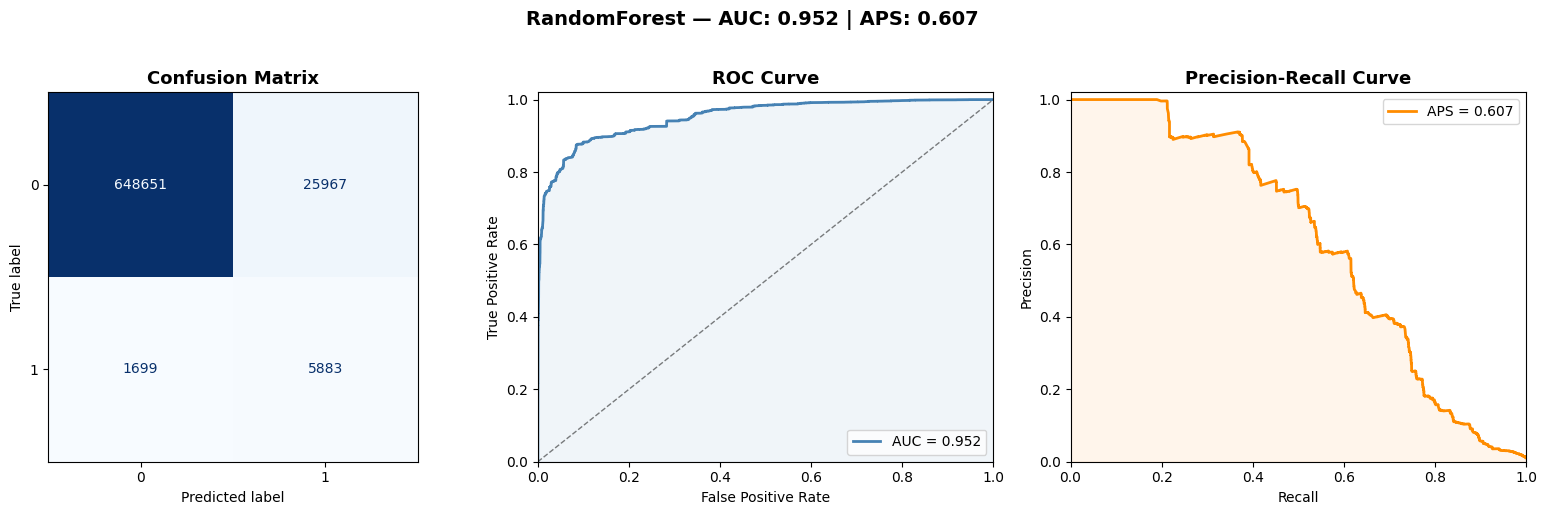

AUC-ROC:  0.9518
Avg Prec: 0.6074


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
clf = RandomForestClassifier(max_depth=2, random_state=42, n_estimators=2000, n_jobs=8, class_weight='balanced')




clf.fit(X_train, y_train)

# Predizioni
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Metriche
auc = roc_auc_score(y_test, y_prob)
aps = average_precision_score(y_test, y_prob)

# Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

# Plot
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# 1 - Confusion Matrix
ax1 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix', fontsize=13, fontweight='bold')

# 2 - ROC Curve
ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax2.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

# 3 - Precision-Recall Curve
ax3 = fig.add_subplot(gs[2])
ax3.plot(recall, precision, color='darkorange', lw=2, label=f'APS = {aps:.3f}')
ax3.fill_between(recall, precision, alpha=0.08, color='darkorange')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.02])

plt.suptitle(
    f'RandomForest — AUC: {auc:.3f} | APS: {aps:.3f}',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC:  {auc:.4f}")
print(f"Avg Prec: {aps:.4f}")


Let's define the model and its parameters:

In [ ]:
#MODEL PARAMETERS
params = {
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "max_depth": -1,
    "learning_rate": 0.1,
    "n_estimators": 5000,
    "subsample_for_bin": 200000,
    "objective": "binary",
    "class_weight": None,
    "min_split_gain": 0.0,
    "min_child_weight": 0.001,
    "min_child_samples": 20,
    "subsample": 1.0,
    "subsample_freq": 0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.1,
    "random_state": GLOBAL_SEED,
    "n_jobs": 8,
    "importance_type": "split",
    "is_unbalance": False,
    "scale_pos_weight": scale_pos_weight,
}

early_stopping_rounds = 50 #number of rounds with no improvement after which training will be stopped, default is None (no early stopping)
log_evaluation = 50 #frequency of logging evaluation results, default is 100, setting it to 50 means that evaluation results will be logged every 50 iterations

#model definition and training with early stopping and evaluation logging
model = lgb.LGBMClassifier(**params)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          eval_metric='binary_logloss',
          callbacks=[lgb.early_stopping(early_stopping_rounds),lgb.log_evaluation(log_evaluation)])



In [ ]:
eval_errors = model.evals_result_
losses = eval_errors['valid_0']['binary_logloss']
best_iter = model.best_iteration_

plt.figure(figsize=(10, 5))
plt.plot(losses, label='LightGBM Validation Log Loss', linewidth=2, color='steelblue')

# linea verticale al best iteration
plt.axvline(x=best_iter, color='tomato', linestyle='--', linewidth=1.5, label=f'Early stopping (iter. {best_iter})')

# annotazione con il valore minimo
plt.annotate(f'min loss: {losses[best_iter]:.4f}',
             xy=(best_iter, losses[best_iter]),
             xytext=(best_iter + len(losses)*0.03, losses[best_iter] + max(losses)*0.05),
             arrowprops=dict(arrowstyle='->', color='tomato'),
             color='tomato', fontsize=10)

plt.xlabel('Iterations')
plt.ylabel('LightGBM Log Loss')
plt.title('Validation Log Loss Over Iterations')
plt.ylim(0, max(losses) * 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Model evaluation



In [ ]:
#Model evaluation on validation set
#Accuracy is useless - we want Precision, Recall, confusion matrix.

y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1] #probability of the positive class

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title('Confusion Matrix - model (validation set)')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.plot(fpr, tpr, marker='.', label='model')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_val, y_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='model') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_val, y_pred_proba):.4f}) - model')
#put legend in upper right corner, where it doesn't cover the curve
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_val, y_pred))
print(f'Average test loss on test set: {log_loss(y_val, y_pred_proba):.4f} - model')

## Test time!
Let's see how well the model does on the test set:

### Baseline Models
As baseline models I chose:

N0: always predicts 0

N1: always predicts 1

R: predicts randomly

In [ ]:
#baseline models:

y_n0 = np.zeros_like(y_test) #baseline model that predicts all transactions as non-fraudulent
y_n1 = np.ones_like(y_test) #baseline model that predicts all transactions as fraudulent
y_r_proba = np.random.rand(y_test.shape[0])  # random probability of class 1
y_r = (y_r_proba >= 0.5).astype(int)

#N0
ConfusionMatrixDisplay.from_predictions(y_test, y_n0)
plt.title('Confusion Matrix - n0')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_n0)
plt.plot(fpr, tpr, marker='.', label='n0')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - n0')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_n0):.4f}) - n0')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_n0)
plt.plot(recall[:-1], precision[:-1], marker='.', label='n0') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - n0')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
#plot ideal precision/recall curve for a perfect model, which is a step function that goes from (0,1) to (1,0)
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_n0):.4f}) - n0')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_n0))
print(f'Average test loss on test set: {log_loss(y_test,y_n0):.4f} - n0')


#N1
ConfusionMatrixDisplay.from_predictions(y_test, y_n1)
plt.title('Confusion Matrix - n1')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_n1)
plt.plot(fpr, tpr, marker='.', label='n1')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - n1')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_n1):.4f}) - n1')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_n1)
plt.plot(recall[:-1], precision[:-1], marker='.', label='n1') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - n1')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_n1):.4f}) - n1')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_n1))
print(f'Average test loss on test set: {log_loss(y_test, y_n1):.4f} - n1')

#random
ConfusionMatrixDisplay.from_predictions(y_test, y_r)
plt.title('Confusion Matrix - random')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y_r_proba)
plt.plot(fpr, tpr, marker='.', label='random')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - random')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y_r_proba):.4f}) - random')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_r_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='random') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - random')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y_r_proba):.4f}) - random')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_r))
print(f'Average test loss on test set: {log_loss(y_test, y_r):.4f} - random')


In [ ]:
y_TEST_pred = model.predict(X_test)
y__TEST_pred_proba = model.predict_proba(X_test)[:, 1] #probability of the positive class

ConfusionMatrixDisplay.from_predictions(y_test, y_TEST_pred)
plt.title('Confusion Matrix - model (test set)')
plt.show()
#print per auc/roc
fpr, tpr, thresholds = roc_curve(y_test, y__TEST_pred_proba)
plt.plot(fpr, tpr, marker='.', label='model')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', color='green', label='Perfect Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (ROC/AUC score: {roc_auc_score(y_test, y__TEST_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y__TEST_pred_proba)
plt.plot(recall[:-1], precision[:-1], marker='.', label='model') #-1 because the last point is (0,1) and is not informative, kinda breaks the plot
plt.fill_between(recall[:-1], precision[:-1], alpha=0.2, color='blue', label='APS Area - model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guess')
plt.plot([0, 1, 1], [1, 1, 0], linestyle='--', color='green', label='Perfect Model')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (APS: {average_precision_score(y_test, y__TEST_pred_proba):.4f}) - model')
plt.legend(bbox_to_anchor=(0.85, 0.1), loc='lower right')
plt.grid(True)
plt.show()
print(classification_report(y_test, y_TEST_pred))
print(f'Average test loss on test set: {log_loss(y_test, y__TEST_pred_proba):.4f} - model')


## Results interpretation
Let's start by looking at the baselines:

n0 and n1 behave as expected: ROC curve perfectly overlapped to the random guess. Precision/Recall curve collapsed in a single point (~0.011, the positive rate.) random shows the same behaviour, with the APS being an actual curve, albeit with a terrible score, again close to the fraud rate.


# Model explainability

In [ ]:
X_test

In [ ]:
#TODO SHAP EXPLAINABILITY ANALYSIS
'''
subsample x_test to 1000-5000 samples to speed up analisys.
'''

# Passo 1: prendi solo le righe dove y_test == 0
X_test_legit = X_test[ y_test==0 ]

# Passo 2: prendi solo le righe dove y_test == 1  
X_test_fraud = X_test[ y_test==1 ]

# Passo 3: campiona N righe da ciascuno e uniscili
X_SHAP_sample = pd.concat([
    X_test_legit.sample(5000, random_state=GLOBAL_SEED),
    X_test_fraud.sample(5000, random_state=GLOBAL_SEED)
])

y_SHAP_sample = pd.concat([
    y_test[X_test_legit.sample(5000, random_state=GLOBAL_SEED).index],
    y_test[X_test_fraud.sample(5000, random_state=GLOBAL_SEED).index]
]).reset_index(drop=True)


X_SHAP_sample = X_SHAP_sample.reset_index(drop=True)


#---EXPLAINER---
explainer = shap.TreeExplainer(model)

#beeswarm plot
shap_values = explainer(X_SHAP_sample)
plt.figure()


shap.plots.beeswarm(shap_values[:, ['distance_km', 'amt', 'trans_month','years','trans_hour', 'city_pop']])

#shap.plots.beeswarm(shap_values[:, ['distance_km', 'amt', 'trans_month']])
#shap.plots.beeswarm(shap_values)
plt.tight_layout()

plt.figure()

#shap.plots.beeswarm(shap_values[:, ['years']])

#shap.plots.beeswarm(shap_values[:, ['trans_hour', 'city_pop']])




amt - key feature. Very long red tail on the left means higher amounts are more typical in frauds. Lower amounts are less definitive, since are more equally distribuited around X=0.

trans_month: needs more investigation. Bimodal?

trans_hour: high values mean more fraudness. //TODO check circular.

years: mixed.

city_pop: mixed, non immediatly conclusive.

distance_km: lower -> anomalous (fraud), higher -> normal

DISCLAIMER: the beeswarm was equilibrated using a non-stratified sample of 5000 frauds and 5000 legit transaction, to declutter positive cases.
 

In [ ]:
df_cat = pd.DataFrame({
    'category': X_SHAP_sample['category'],
    'shap': shap_values[:,'category'].values
}).pivot(columns='category', values='shap')

medians = df_cat.median()
colors = ['yellow' if m > 0 else 'darkgreen' for m in medians]
data = [df_cat[col].dropna().values for col in df_cat.columns]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data, patch_artist=True, labels=df_cat.columns)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticklabels(df_cat.columns, rotation=45, ha='right')
ax.set_ylim(-20, 20)
ax.set_ylabel('SHAP value')
ax.set_xlabel('Category')
ax.set_title('Category SHAP values impact on target "isFraud"')

from matplotlib.patches import Patch
legend = [Patch(facecolor='yellow', label='Pushes towards fraud'),
          Patch(facecolor='darkgreen', label='Pushes towards non-fraud')]
ax.legend(handles=legend)

plt.tight_layout()
plt.show()


In [ ]:
#shap_values

### Legit transaction

In [ ]:
shap.plots.waterfall(shap_values[0]) # "random" legit transaction
print('Probability of fraud for this transaction:', model.predict_proba(X_SHAP_sample.iloc[[0]])[0][1])
print('True label for this transaction:', y_SHAP_sample.iloc[0])

E(f(x)) is the average of the whole sample (n=5000).
profile, gender and city pop are not very conclusive, as per beeswarm plot.
amt is on the higher side, but the distance and category bring it down. It gets correctly classified as "legit".

### Fraud transaction

In [ ]:
shap.plots.waterfall(shap_values[5000]) # "random" fraud transaction
print('Probability of fraud for this transaction:', model.predict_proba(X_SHAP_sample.iloc[[5000]])[0][1])
print('True label for this transaction:', y_SHAP_sample.iloc[5000])

distance in km is not sufficiently high to look safe. Gender, profile and city pop are not very conclusive.

75 is considered "at risk" age, november+16 is considered "at risk" for the model.
The high amount and the category are the final nail in the coffin.

### False positive (1219)

In [ ]:
shap.plots.waterfall(shap_values[1219]) # false positive
print('Probability of fraud for this transaction:', model.predict_proba(X_SHAP_sample.iloc[[1219]])[0][1])
print('True label for this transaction:', y_SHAP_sample.iloc[1219])


It's obvious that "amt" is responsible for flagging this transaction. High amount & risk category => fraud for the model.

### False negative (5007)

In [ ]:
shap.plots.waterfall(shap_values[5007]) # false negative transaction
print('Probability of fraud for this transaction:', model.predict_proba(X_SHAP_sample.iloc[[5007]])[0][1])
print('True label for this transaction:', y_SHAP_sample.iloc[5007])

low amt and high hour are BOTH at risk => clear case of "card test" - small transaction to see if the stolen credentials work. Hence, at risk. The model seems to have learned this case, very common before the true fraud comes in. Unfortunately, the other features don't help enough in catching it.

### Uncertain, borderline case (5629)

In [ ]:
shap.plots.waterfall(shap_values[5629]) # dubious transaction, borderline case
print('Probability of fraud for this transaction:', model.predict_proba(X_SHAP_sample.iloc[[5629]])[0][1])
print('True label for this transaction:', y_SHAP_sample.iloc[5629])

### Local SHAP summary

| | **f(x)** | **Prediction** | **Actual class** | **Predicted class** | **Reasons** |
|---|---|---|---|---|---|
| Legit transaction | −16.199 | Legit | Legit | ✅ True Negative | `amt` not alarming (115.89) + category `kids_pets` lower the risk |
| fraud transaction| +21.729 | Fraud | Fraud | ✅ True Positive | `shopping_net` (+10.93) and `amt` high (774.1, +10.04) converge to fraud |
| False positive | +2.944 | Fraud | Legit | ❌ False Positive | `amt` mid-high (286.97, +10.81) + generic `grocery_pos` increase the risk |
| False negative | −4.178 | Legit | Fraud | ❌ False Negative | `amt` too low (8.69) to activate the main model signal. |

In [ ]:
#False positive/negative finder
'''
for i in range(10000):
    if model.predict(X_SHAP_sample.iloc[[i]]) == 1 and y_SHAP_sample[i] == 0:
        print(str(i)+'pass: '+str(model.predict_proba(X_SHAP_sample.iloc[[i]])[0]))
'''

# Bandits time!
In this section we tackle the cost problem, bank side! Sure, the algo we just tested can predict if a transaction is likely to be a fraud, but we can't afford to investigate all the positives! The problem to solve is: given a transaction with features x and with P(x=Fraud) = p, is it worth it for the bank to pursue the investigation?

In [ ]:
y_train

## Bandits preprocessing
For the bandit section, we have some choices to make. First of all, how many features should be included in our context?

In [ ]:
#count how many transaction labeled isfrauds 1 were M and F in the train set.
X_train[y_train == 1]['gender'].value_counts()
X_train[y_train == 0]['profile'].value_counts() #todo calcola percentuali per ogni categoria, non solo count, altrimenti è difficile capire se una categoria è più fraudolenta di un'altra o se semplicemente è più rappresentata nel dataset.


# fraud rate per age group
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100] #todo mostra grafico con tanti gruppi
#age_bins = [0,50,100] #per semplicità, dividiamo in 2 gruppi: under 50 e over 50, così da avere più dati in ogni gruppo e rendere il grafico più leggibile
age_group = pd.cut(X_train['years'], bins=age_bins)

# y_train contains the labels, so aggregate y_train by the age groups
age_group_fraud_rate = y_train.groupby(age_group, observed=False).mean()

age_group_fraud_rate.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Age Group')
plt.show()


In [ ]:
#TODO
"""
prendi X_test #TODO motiva bene data leakage su p
calcola p_fraud eseguendo model.predict.proba
appendi p_fraud a X_test
dividi in X_sim e X_prod con scikit
applica il preprocessor
applica il bandi_preprocessor (merge dei due?)
"""

def bandits_preprocessing(X):
    #category one-hot encoding
    #X = pd.get_dummies(X, columns=['category'], dtype=int) #CATEGORY BAD!
    X['gender'] = X['gender'].map({'F': 0, 'M': 1})
    X['profile'] = X['profile'].map({'rural': 0, 'urban': 1})    
    return X



In [ ]:
X_b = X_test.copy() #TODO remove X_test from memory - efficiency (decomment line below)
#del X_test 


#---get predictions from SL model
#LightGBM_actions = model.predict(X_b)+1 #get actions from LightGBM model, these will be used as a baseline for the bandit model, TODO - maybe we can use the predicted probabilities instead of the binary predictions, to give more information to the bandit model? da testare
X_b['p_fraud'] = model.predict_proba(X_b)[:,1] #add p_fraud to dataset before preprocessing using the LightGBM model trained above

#preprocessing for bandits
X_bf = bandits_preprocessing(X_b) #TODO sostituire X_bf con X_b dopo il testing
#print(X_bf.head()) #check if preprocessing is correct, se tutto ok sostituisci X_bf con X_b e rimuovi questa print


Reward lookup table, for clean code (way better and scalable than elif chain)

|     _REWARDS_    | **Transaction: legit [0]** | **Transaction: fraud [1]** |
|:--------------------:|----------------|----------------|
| **Action: ACCEPT [0]**  | +0        | -amount        |
| **Action: BLOCK [1]** | -labour cost          | +amount-labour cost          |

Accepting a legit transaction has no cost at all.

Accepting a fraudolent transaction makes so the bank loses money

Blocking a legit one makes you lose the analyst's wage

Blocking a fraudolent one makes you lose the analyst's wage, but you gain back the transaction amount that would otherwise be lost.

In [ ]:
X_test

In [ ]:
y_test

In [ ]:
#DEBUG - this exists only to check the output of the context
#print(build_context(X_test.iloc[0]))

In [ ]:
#ORIGINAL Reward table lookup:
def get_reward(context, truth, action):
    action = action - 1 #convert action to 0-indexed for table lookup
    labour_cost = 32.5
    amount = context['amt']
    table = np.array([
        [0,             -amount],
        [-labour_cost,  amount-labour_cost]]) #todo rimetti amount-labour_cost
    #print('[0,0]', table[0,0], '[0,1]', table[0,1], '[1,0]', table[1,0], '[1,1]', table[1,1]) #print reward table for debugging
    return table[action, truth]



def build_context(row):
    # tutte le colonne tranne p_fraud sono già numeriche
    feature_cols = ['gender','city_pop','years','profile','trans_month','trans_hour','amt','distance_km'] #CATEGORY BAD
    
    #feature_cols = ['amt']
    #feature_cols = ''
    num_fs = " ".join(f"{f}:{row[f]}" for f in feature_cols)
    context = f"| p_fraud:{row['p_fraud']} {num_fs}"
    #context = f"| {num_fs}"
    #context = f"| ev:{row['p_fraud'] * row['amt']:.4f}"
    #return f"| p_fraud:{row['p_fraud']} {num_fs}"
    return context



def learning_info(action, reward, prob, context):
    return f"{action}:{reward}:{prob} {context}"




def choose_action(learner, context):
    probs = learner.predict(context) #learner outputs probability for each action
    
    probs = np.array(probs) #ensure it's a numpy array for the next operation
    probs = probs / probs.sum()  # renormalize - FIX NUMERICAL ERRORS
    
    action = np.random.choice(len(probs), p=probs) + 1  # 1-indexed choice for action
    #action = np.random.choice(len(probs), p=probs)  # 0 indexed choice for action (REMEMBER TO PUT IT 1-INDEXED FOR LEARNER)
    prob = probs[action-1] #misticanza, output della probabilità con cui è stata scelta action
    return prob, action


def oracle_action(row, truth, labour_cost):
    #return best action
    return max([(0,1), (1,2)], key=lambda x: get_reward(row, truth, x[1]))[1] #calcola reward per entrambe le azioni e restituisce quella con reward più alto

def lightgbm_action(row, threshold):
    return 2 if row['p_fraud'] > threshold else 1


def random_action():
    return np.random.choice([1,2]) #1-indexed random action

from vowpalwabbit import pyvw

#parameters
EPSILON = 0.05
labour_cost = 32.5 #TODO parametrizza, ora è inutile


#build a learner with 2 actions
learner = pyvw.Workspace("--cb_explore 2 --epsilon 0.1 --cb_type dr", quiet=True)



rewards = []
regrets = []

oracle_rewards = []
LightGBM_rewards = []

naive_never_rewards = []
naive_always_rewards = []
naive_random_rewards = []

#LEARNING LOOP
for i in range(X_bf.shape[0]):
#for i in range(100):


    #-----LEARNER-----
    
    #build context
    row = X_bf.iloc[i]
    context = build_context(row)
    #print(context) #DEBUG - check context format, if ok remove this print
    
    #choose action in correct format
    prob, action = choose_action(learner,context) #NB: this action is 1-indexed
    #action = learner.predict(context)
    #print(action)
    truth = y_test.iloc[i]
    
    #calculate reward
    reward = get_reward(row, truth, action) #get reward for the chosen action (1-indexed, internal conversion)
    rewards.append(reward)
    #print(reward)
    
    #progress bar
    if (i+1) % 5000 == 0:
        print(f"Processed {i+1} samples - % completed: {(i+1)/X_bf.shape[0]*100:.2f}% - Average reward: {np.mean(rewards):.4f}")

    learner.learn(learning_info(action,-reward,prob,context)) #LEARNER WANTS COSTS - NOT REWARDS! lower is better
    
    #-----ORACLE-----
    oracle_rewards.append(get_reward(row,truth,oracle_action(row, truth, labour_cost))) #get reward for oracle action
    
    #----LIGHTGBM-----
    #LightGBM_rewards.append(get_reward(row,truth,LightGBM_actions[i]))
    LightGBM_rewards.append(get_reward(row,truth,lightgbm_action(row, 0.5))) 
    
    #-----NAIVE BASELINES-----
    naive_never_rewards.append(get_reward(row, truth, 1))   # action=1: non investigare mai
    naive_always_rewards.append(get_reward(row, truth, 2))  # action=2: investiga sempre
    naive_random_rewards.append(get_reward(row, truth, random_action()))
    
learner.finish()




In [ ]:
# --- Cumsum ---
cum_learner = np.cumsum(rewards)
cum_oracle  = np.cumsum(oracle_rewards)
cum_lgbm    = np.cumsum(LightGBM_rewards)
cum_never   = np.cumsum(naive_never_rewards)
cum_always  = np.cumsum(naive_always_rewards)
cum_random  = np.cumsum(naive_random_rewards)

lines = [
    (cum_oracle,  'Oracle',           'gold'),
    (cum_lgbm,    'LightGBM',         'green'),
    (cum_learner, 'CB Learner',       'blue'),
    (cum_never,   'Never Investigate','red'),
    (cum_always,  'Always Investigate','purple'),
    (cum_random,  'Random',           'orange')
]

# --- REWARD PLOT ---
fig, ax = plt.subplots(figsize=(12, 5))
for cum, label, color in lines:
    ax.plot(range(len(cum)), cum, label=label, color=color)
    ax.annotate(
        f"{label}: {cum[-1]:,.0f}",
        xy=(len(cum)-1, cum[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        color=color,
        va='center',
        fontweight='bold'
    )
ax.set_xlabel('Iterations')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward — tutti i sistemi')
ax.legend(loc='upper left')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

# --- REGRET PLOT ---
fig, ax = plt.subplots(figsize=(12, 5))
regret_lines = [
    (cum_oracle  - cum_oracle,  'Oracle (baseline)', 'gold'),
    (cum_oracle  - cum_lgbm,    'LightGBM',          'green'),
    (cum_oracle  - cum_learner, 'CB Learner',        'blue'),
    (cum_oracle  - cum_never,   'Never Investigate', 'red'),
    (cum_oracle  - cum_always,  'Always Investigate','purple'),
    (cum_oracle  - cum_random,  'Random',            'orange')
]
for reg, label, color in regret_lines:
    ax.plot(range(len(reg)), reg, label=label, color=color)
    ax.annotate(
        f"{label}: {reg[-1]:,.0f}",
        xy=(len(reg)-1, reg[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        color=color,
        va='center',
        fontweight='bold'
    )
ax.set_xlabel('Iterations')
ax.set_ylabel('Cumulative Regret')
ax.set_title('Cumulative Regret — tutti i sistemi')
ax.legend(loc='upper left')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()
